In [1]:
""" pip install mysql-connector-python """

' pip install mysql-connector-python '

In [2]:
""" pip show mysql-connector-python """

' pip show mysql-connector-python '

In [3]:
""" pip install mysql-connector-python==8.1.0 """

' pip install mysql-connector-python==8.1.0 '

In [4]:
import mysql.connector  
import pandas as pd  
import seaborn as sns  
import matplotlib.pyplot as plt 
import numpy as np

In [5]:
conn = mysql.connector.connect(
    host="192.168.0.4",     # MySQL 서버 주소
    user="farmorai_admin", # MySQL 사용자명
    password="farmorai12345", # MySQL 비밀번호
    database="farmdb"  # 사용할 데이터베이스 이름
)
# 연결 확인
if conn.is_connected():
    print("MySQL 데이터베이스에 성공적으로 연결되었습니다.")


MySQL 데이터베이스에 성공적으로 연결되었습니다.


In [6]:
cursor = conn.cursor()
cursor.execute("SELECT cate3, width, height, weight FROM apple_label_dataset")

rows = cursor.fetchall()

df = pd.DataFrame(rows, columns=['cate3', 'width', 'height', 'weight'])
print(df)


     cate3  width  height  weight
0        특    8.8     8.1   334.0
1        특    8.8     8.1   334.0
2        특    8.8     8.1   334.0
3        특    8.8     8.1   334.0
4        특    8.8     8.1   334.0
...    ...    ...     ...     ...
1559    보통    7.8     6.3   200.0
1560    보통    8.3     7.9   265.0
1561    보통    7.8     6.3   200.0
1562    보통    8.3     7.9   265.0
1563    보통    7.8     6.3   200.0

[1564 rows x 4 columns]


In [7]:
df['cate3'] =df['cate3'].map({'특':2, '상':1, '보통':0}) 

In [8]:
# 상관관계 분석
correlation_matrix = df.corr()
print(correlation_matrix)

           cate3     width    height    weight
cate3   1.000000  0.812743  0.660840  0.893552
width   0.812743  1.000000  0.726724  0.923327
height  0.660840  0.726724  1.000000  0.850846
weight  0.893552  0.923327  0.850846  1.000000


d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu S

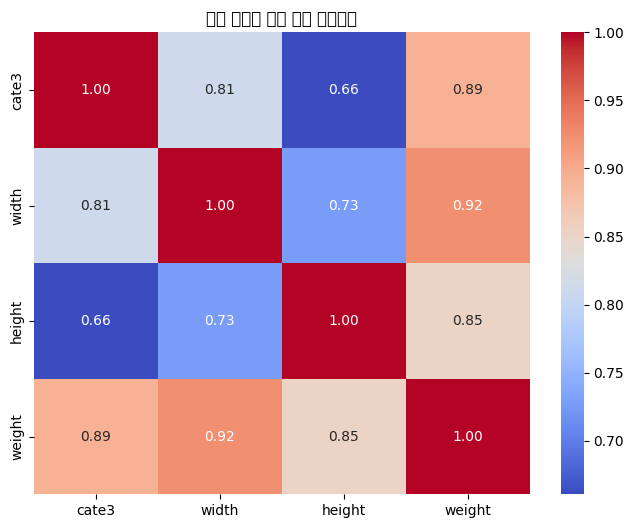

In [9]:
# 상관관계 히트맵
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("사과 크기와 등급 간의 상관관계")
plt.show()

<Figure size 1000x500 with 0 Axes>

d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) D

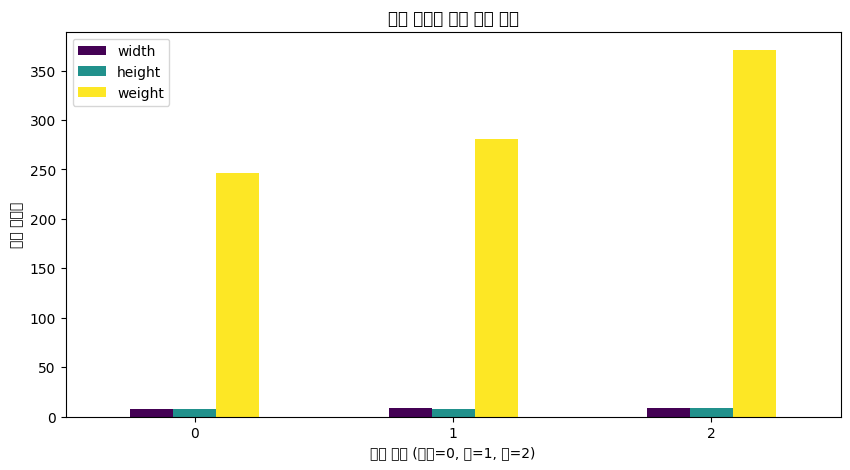

In [10]:
# 등급별 평균 크기 시각화
grouped_df = df.groupby('cate3')[['width', 'height', 'weight']].mean()

plt.figure(figsize=(10, 5))
grouped_df.plot(kind='bar', figsize=(10, 5), colormap='viridis')
plt.title("사과 등급별 평균 크기 비교")
plt.ylabel("크기 평균값")
plt.xlabel("사과 등급 (보통=0, 상=1, 특=2)")
plt.xticks(rotation=0)
plt.legend(["width", "height", "weight"])
plt.show()

In [11]:
""" pip install scipy """

' pip install scipy '

In [12]:
print(df["cate3"].value_counts())


cate3
0    522
2    521
1    521
Name: count, dtype: int64


In [13]:
from scipy.stats import f_oneway

# ANOVA 검정
# 등급별 무게 데이터 추출
grade_0 = df[df["cate3"] == 0]["weight"]  # cate3이 0인 데이터
grade_1 = df[df["cate3"] == 1]["weight"]  # cate3이 1인 데이터
grade_2 = df[df["cate3"] == 2]["weight"]  # cate3이 2인 데이터

# ANOVA 검정 수행
from scipy.stats import f_oneway

stat, p = f_oneway(grade_0, grade_1, grade_2)

print(f"F-statistic: {stat:.2f}, p-value: {p:.4f}")

F-statistic: 4412.48, p-value: 0.0000


d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaV

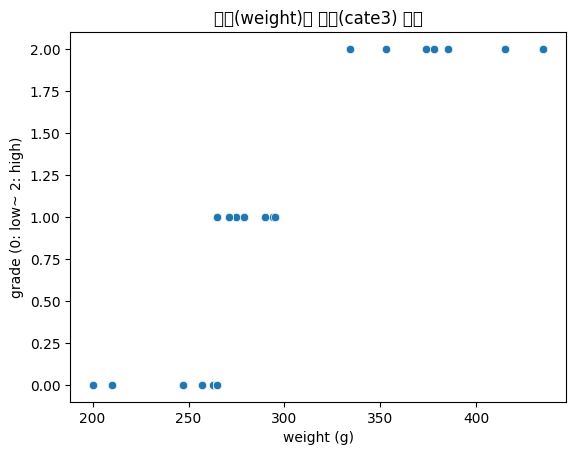

In [14]:
#산점도로 무게와 등급 관계 확인
sns.scatterplot(x=df["weight"], y=df["cate3"])
plt.title("무게(weight)와 등급(cate3) 관계")
plt.xlabel("weight (g)")
plt.ylabel("grade (0: low~ 2: high)")
plt.show()


In [15]:
# 부피 계산하여 등급과 관계 파악
df["volume"] = (4/3) * np.pi * (df["width"] / 2) ** 2 * (df["height"] / 2)

d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu S

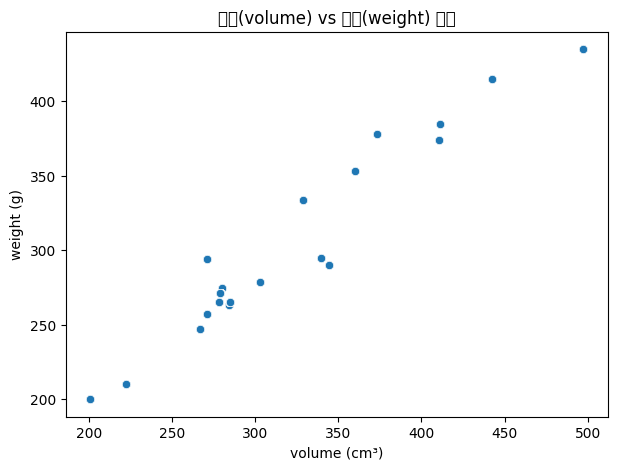

In [16]:
# 부피 무게 확인용
plt.figure(figsize=(7, 5))
sns.scatterplot(x=df["volume"], y=df["weight"])
plt.title("부피(volume) vs 무게(weight) 관계")
plt.xlabel("volume (cm³)")
plt.ylabel("weight (g)")
plt.show()

d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) Dej

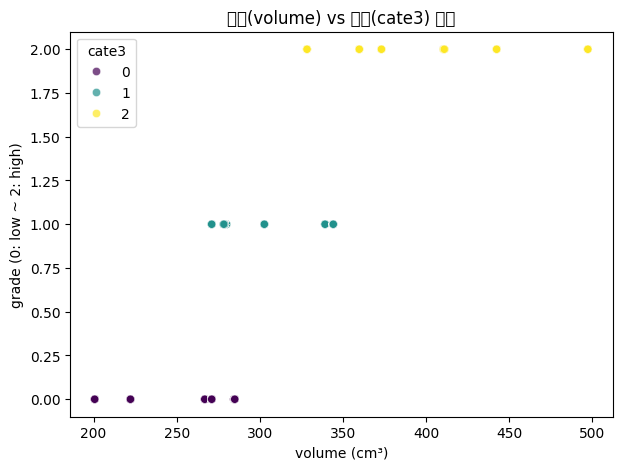

In [17]:
# 부피 등급
plt.figure(figsize=(7, 5))
sns.scatterplot(x=df["volume"], y=df["cate3"], hue=df["cate3"], palette="viridis", alpha=0.7)
plt.title("부피(volume) vs 등급(cate3) 관계")
plt.xlabel("volume (cm³)")
plt.ylabel("grade (0: low ~ 2: high)")
plt.show()

In [18]:
print(df[["volume", "weight", "cate3"]].corr())

          volume    weight     cate3
volume  1.000000  0.955569  0.792764
weight  0.955569  1.000000  0.893552
cate3   0.792764  0.893552  1.000000


####분산

In [19]:
# 각 변수별 분산 확인
print(df[["width", "height", "weight", "volume"]].var())

width        0.274279
height       0.448857
weight    3245.791078
volume    3776.352096
dtype: float64


In [20]:
print(df.groupby("cate3")[["width", "height", "weight", "volume"]].var())


          width    height      weight       volume
cate3                                             
0      0.078122  0.174080  523.527452   832.583694
1      0.043769  0.167689  120.542071   517.455774
2      0.153315  0.163874  821.255551  2067.169629


d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) D

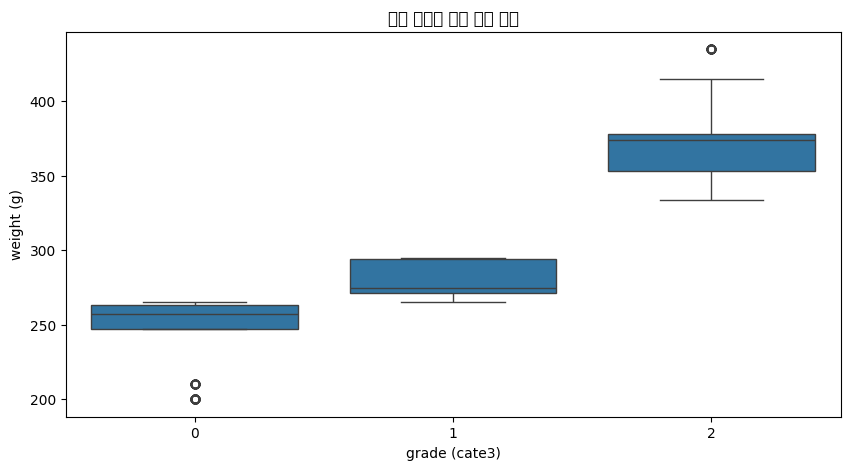

In [21]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="cate3", y="weight", data=df)
plt.title("사과 등급별 무게 분산 비교")
plt.xlabel("grade (cate3)")
plt.ylabel("weight (g)")
plt.show()

C:\Users\KOSMO\AppData\Local\Temp\ipykernel_8152\1437403299.py:6: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KOSMO\AppData\Local\Temp\ipykernel_8152\1437403299.py:6: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KOSMO\AppData\Local\Temp\ipykernel_8152\1437403299.py:6: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KOSMO\AppData\Local\Temp\ipykernel_8152\1437403299.py:6: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KOSMO\AppData\Local\Temp\ipykernel_8152\1437403299.py:6: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KOSMO\AppData\Local\Temp\ipykernel_8152\1437403299.py:6: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s)

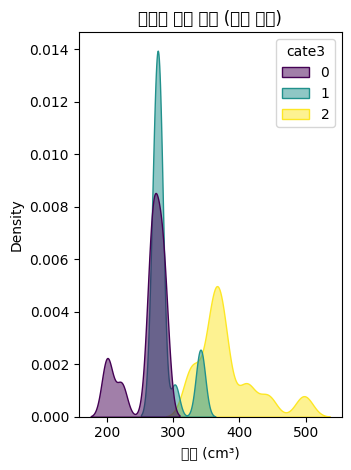

In [22]:
plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x="volume", hue="cate3", fill=True, palette="viridis", alpha=0.5)
plt.title("등급별 부피 분포 (밀도 플롯)")
plt.xlabel("부피 (cm³)")

plt.tight_layout()
plt.show()

           volume      weight
cate3                        
0      261.587671  246.047893
1      286.670190  281.015355
2      380.884251  370.702495


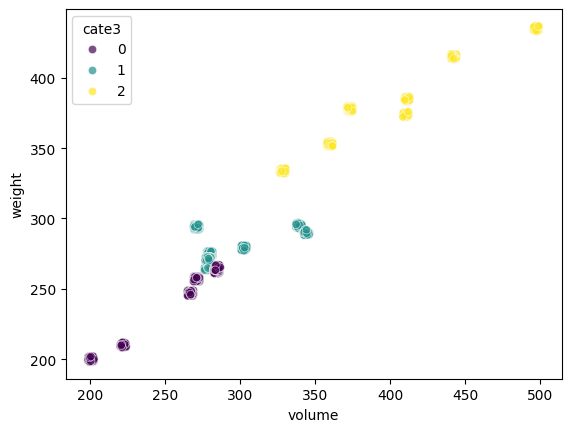

d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing from font(s) DejaVu

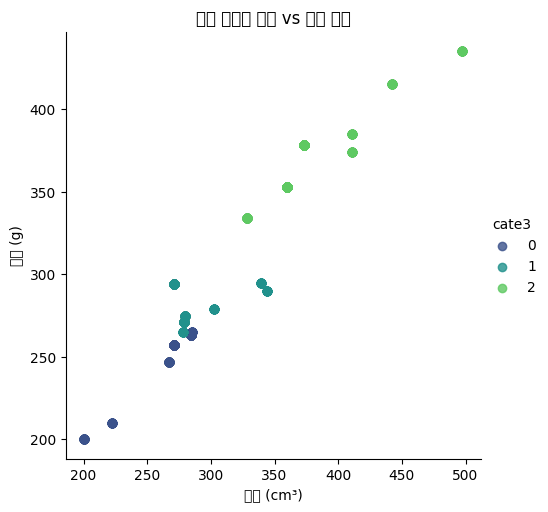

In [23]:
print(df.groupby("cate3")[["volume", "weight"]].mean())
sns.scatterplot(x=df["volume"] + np.random.uniform(-2, 2, size=len(df)), 
                y=df["weight"] + np.random.uniform(-2, 2, size=len(df)), 
                hue=df["cate3"], palette="viridis", alpha=0.7)

sns.lmplot(x="volume", y="weight", hue="cate3", data=df, scatter=True, fit_reg=False, palette="viridis")
plt.title("사과 등급별 부피 vs 무게 분포")
plt.xlabel("부피 (cm³)")
plt.ylabel("무게 (g)")
plt.show()

In [24]:
df.shape

(1564, 5)

In [25]:
# 상관관계 분석
correlation_matrix = df.corr()
print(correlation_matrix)

           cate3     width    height    weight    volume
cate3   1.000000  0.812743  0.660840  0.893552  0.792764
width   0.812743  1.000000  0.726724  0.923327  0.947681
height  0.660840  0.726724  1.000000  0.850846  0.899281
weight  0.893552  0.923327  0.850846  1.000000  0.955569
volume  0.792764  0.947681  0.899281  0.955569  1.000000
